<a href="https://colab.research.google.com/github/Pradeep333Singh/Pw_Assignments_DataScience/blob/main/Pw_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PW Assignment

**Ques 1: What is Deep Learning?**

Answer:


Deep Learning is a subfield of machine learning based on artificial neural networks with multiple layers (hence "deep") that attempt to mimic the human brain's ability to learn from large amounts of data.


- Evolution: It evolved from early simple perceptrons in the 1950s to multilayer networks, eventually gaining massive traction in the 2010s due to the availability of big data and powerful GPU computing.


- Differences from Traditional ML: * Feature Extraction: Traditional ML often requires manual "feature engineering" by experts, whereas Deep Learning automatically discovers the hierarchy of features from raw data.


   - Data Dependency: Deep Learning performance continues to improve as data volume increases, whereas traditional ML performance often plateaus.


  - Complexity: Deep Learning models require significantly more computational power and data compared to traditional algorithms like Linear Regression or Decision Trees.

**Question 2: Explain the basic architecture and functioning of a Perceptron. What are its limitations?**

Answer:

A Perceptron is the simplest form of a neural network used for binary classification.
 - Architecture: It consists of input values ($x_1, x_2, ... x_n$), corresponding weights ($w_1, w_2, ... w_n$), a bias ($b$), a weighted sum ($z = \sum (w_i x_i) + b$), and an activation function (typically a step function).
 - Functioning: It calculates the weighted sum of inputs; if the sum exceeds a certain threshold (determined by the activation function), the perceptron "fires" (outputs 1), otherwise it outputs 0.

  - Limitations:
    - Linear Separability: The biggest limitation is that a single-layer perceptron can only solve linearly separable problems (it cannot solve the XOR gate).
  
    - Binary Output: It is generally limited to simple binary classification tasks.

**Question 3: Describe the purpose of activation function in neural networks.
Compare Sigmoid, ReLU, and Tanh functions.**

Answer:

The Activation Function introduces non-linearity into the network, allowing it to learn complex patterns and solve non-linear problems. Without it, a neural network, regardless of layers, would behave like a simple linear regression model.

**Question 4: What is the difference between Loss function and Cost function in neural networks? **
Provide examples.

Answer:

While often used interchangeably, there is a technical distinction:


- Loss Function: Refers to the error of a single training example.


  - Example: Binary Cross-Entropy for one specific prediction vs. one actual label.


 - Cost Function: Refers to the average of the loss functions over the entire training dataset.


   - Example: Mean Squared Error (MSE) calculated across the whole batch or dataset.

**Question 5: What is the role of optimizers in neural networks?
Compare Gradient Descent, Adam, and RMSprop.**

Answer:


Optimizers are algorithms used to update the weights and learning rate of the neural network to minimize the cost function.

- Gradient Descent: The basic optimizer. It updates weights in the opposite direction of the gradient. It can be slow and get stuck in local minima.


- RMSprop: Addresses the diminishing learning rate by using a moving average of squared gradients to normalize the gradient.

- Adam (Adaptive Moment Estimation): Combines the benefits of RMSprop and Momentum. It is generally the "go-to" optimizer because it handles noisy gradients and sparse data efficiently.

**Question 6: Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.**

In [3]:
import numpy as np

# Inputs for AND gate
X = np.array([[0,0], [0,1], [1,0], [1,1]])
# Target outputs
y = np.array([0, 0, 0, 1])

class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=10):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

    def activation(self, x):
        return 1 if x >= 0 else 0

    def fit(self, X, y):
        for _ in range(self.epochs):
            for i in range(len(y)):
                z = np.dot(X[i], self.weights) + self.bias
                prediction = self.activation(z)
                # Weight update: w = w + lr * (error) * x
                error = y[i] - prediction
                self.weights += self.lr * error * X[i]
                self.bias += self.lr * error

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return np.array([self.activation(i) for i in z])

# Train and Test
model = Perceptron()
model.fit(X, y)
predictions = model.predict(X)

print(f"Weights: {model.weights}")
print(f"Bias: {model.bias}")
print(f"AND Gate Predictions: {predictions}")

Weights: [0.2 0.1]
Bias: -0.20000000000000004
AND Gate Predictions: [0 0 0 1]


**Question 7: Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib.**

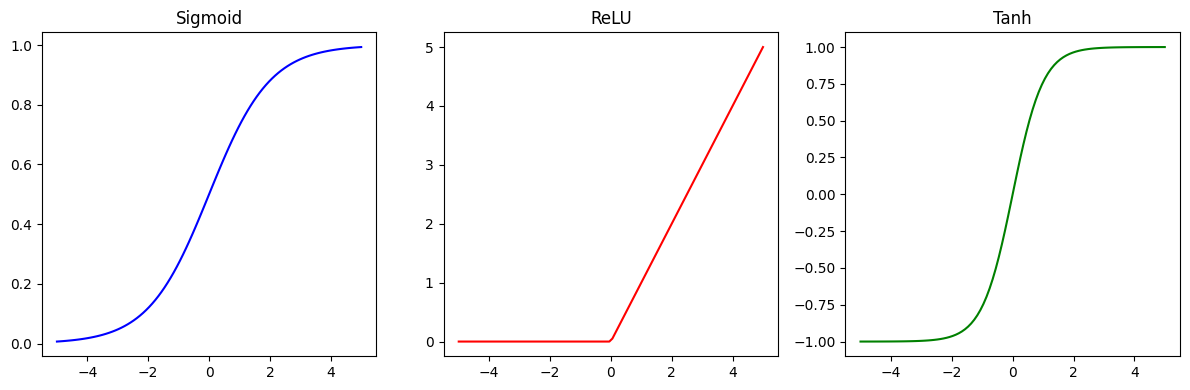

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

x = np.linspace(-5, 5, 100)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, sigmoid(x), color='blue')
plt.title("Sigmoid")

plt.subplot(1, 3, 2)
plt.plot(x, relu(x), color='red')
plt.title("ReLU")

plt.subplot(1, 3, 3)
plt.plot(x, tanh(x), color='green')
plt.title("Tanh")

plt.tight_layout()
plt.show()

**Question 8: Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset.**

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load MNIST
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0 # Normalize

# Build Model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=5, verbose=1)

# Print Final Training Accuracy
print(f"\nFinal Training Accuracy: {history.history['accuracy'][-1]:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8621 - loss: 0.4794
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9551 - loss: 0.1542
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9673 - loss: 0.1078
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9714 - loss: 0.0902
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9751 - loss: 0.0765

Final Training Accuracy: 0.9757


**Question 9: Visualize the loss and accuracy curves for a neural network model trained on the Fashion MNIST dataset.**

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


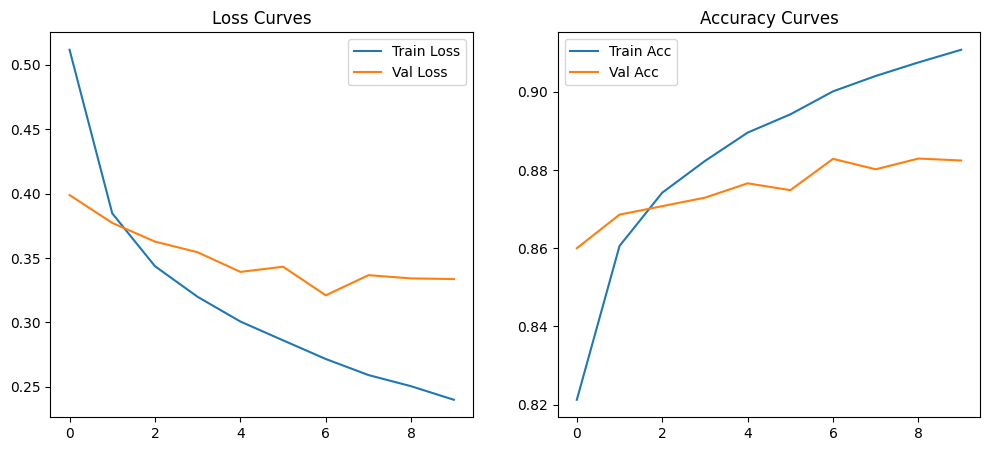

In [6]:
# Load Fashion MNIST
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Build and Train Model
model_f = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_f.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_f = model_f.fit(x_train, y_train, epochs=10, validation_split=0.2, verbose=0)

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_f.history['loss'], label='Train Loss')
plt.plot(history_f.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_f.history['accuracy'], label='Train Acc')
plt.plot(history_f.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()

plt.show()

# Interpretation:
# If Val Loss starts increasing while Train Loss decreases, the model is Overfitting.
# If both decrease and plateau, the model is converging well.

**Question 10: Fraud Detection Workflow Scenario: Detecting fraudulent bank transactions in a large, imbalanced, structured dataset.**

Answer:

- Model Design: I would design a Multilayer Neural Network (MLP). Perceptrons cannot handle the non-linear relationships between features like merchant ID and location.

- Activation & Loss:
  - Activation: ReLU for hidden layers (to avoid vanishing gradients) and Sigmoid for the output layer (since it is a binary classification: Fraud vs. Legitimate).
  - Loss: Binary Cross-Entropy, which is standard for binary classification.

- Training & Evaluation (Imbalance): * Since the data is imbalanced, I would use Class Weights during training or SMOTE to oversample the minority class.
   - Evaluation should focus on Precision-Recall AUC or F1-Score rather than accuracy.
   
- Optimizer & Overfitting:
  - Optimizer: Adam for its efficiency with large datasets.
  - Overfitting: Use Dropout layers, L2 Regularization, and Early Stopping to ensure the model generalizes well to new transactions.